In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Is there a relationship between the win rate of platers and the number of cities in which they've played?

In [55]:
home_team_df  = pd.read_csv("../home_team.csv")
away_team_df  = pd.read_csv("../away_team.csv")
match_event_df = pd.read_csv("../event.csv")
venue_df = pd.read_csv("../venue.csv")

In [57]:
match_event_df = match_event_df[["match_id", "winner_code"]].copy()
match_event_df = match_event_df.dropna(subset=["match_id", "winner_code"])

match_event_df = match_event_df[match_event_df["winner_code"].isin([1, 2])]
match_event_df = match_event_df.drop_duplicates(subset=["match_id"])


In [58]:
venue_df = venue_df[["match_id", "city"]].copy()
venue_df = venue_df.dropna(subset=["match_id", "city"])
venue_df["city"] = venue_df["city"].str.strip().str.title()

# Drop clearly invalid city names
venue_df = venue_df[venue_df["city"].str.len() > 1]
venue_df = venue_df.drop_duplicates(subset=["match_id"])

In [59]:
home_team_df = home_team_df[["match_id", "player_id"]].copy()
away_team_df = away_team_df[["match_id", "player_id"]].copy()

home_team_df = home_team_df.dropna(subset=["match_id", "player_id"])
away_team_df = away_team_df.dropna(subset=["match_id", "player_id"])

home_team_df["match_id"] = home_team_df["match_id"].astype(int)
away_team_df["match_id"] = away_team_df["match_id"].astype(int)
home_team_df["player_id"] = home_team_df["player_id"].astype(int)
away_team_df["player_id"] = away_team_df["player_id"].astype(int)

home_team_df = home_team_df.drop_duplicates(subset=["match_id"])
away_team_df = away_team_df.drop_duplicates(subset=["match_id"])


In [60]:
match_df = (match_event_df
    .merge(venue_df, on="match_id", how="inner")
    .merge(home_team_df.rename(columns={"player_id": "home_player_id"}), on="match_id", how="inner")
    .merge(away_team_df.rename(columns={"player_id": "away_player_id"}), on="match_id", how="inner"))

In [61]:
home_rows = match_df[["match_id", "home_player_id", "city", "winner_code"]].copy()
home_rows["player_id"] = home_rows["home_player_id"]
home_rows["won"] = (home_rows["winner_code"] == 1).astype(int)

away_rows = match_df[["match_id", "away_player_id", "city", "winner_code"]].copy()
away_rows["player_id"] = away_rows["away_player_id"]
away_rows["won"] = (away_rows["winner_code"] == 2).astype(int)

player_df = pd.concat(
    [home_rows[["match_id", "player_id", "city", "won"]],
     away_rows[["match_id", "player_id", "city", "won"]]],
    ignore_index=True)


In [62]:
player_stats = (player_df.groupby("player_id")
    .agg(
        total_matches=("won",  "count"),
        total_wins=("won",    "sum"),
        distinct_cities=("city", "nunique"))
    .reset_index())

player_stats["win_rate"] = (
    player_stats["total_wins"] / player_stats["total_matches"]).round(4)

player_stats = player_stats[player_stats["total_matches"] >= 10]
print(f"Players remaining after min-match filter: {len(player_stats):,} \nKeep only players who had over 10 matches to be statistically meaningful")



Players remaining after min-match filter: 827 
Keep only players who had over 10 matches to be statistically meaningful


In [63]:
city_bins   = [0, 1, 2, 3, 4, 5, 6, 7, np.inf]
city_labels = ["1", "2", "3", "4", "5", "6", "7", "8+"]

player_stats["city_group"] = pd.cut(
    player_stats["distinct_cities"],
    bins=city_bins,
    labels=city_labels,)

result = (player_stats
    .groupby("city_group", observed=True)
    .agg(
        total_players=("player_id",    "count"),
        avg_win_rate=("win_rate",      "mean"),
        median_win_rate=("win_rate",   "median"),
        avg_matches=("total_matches",  "mean"))
    .reset_index()
    .assign(
        avg_win_rate=lambda d:    (d["avg_win_rate"]    * 100).round(2),
        median_win_rate=lambda d: (d["median_win_rate"] * 100).round(2),
        avg_matches=lambda d:      d["avg_matches"].round(1)))

print("\nWin Rate by Number of Distinct Cities Played In:\n")
print(result.to_string(index=False))



Win Rate by Number of Distinct Cities Played In:

city_group  total_players  avg_win_rate  median_win_rate  avg_matches
         1             28         59.51            60.77         12.8
         2             54         66.69            66.67         12.1
         3            109         63.45            64.29         12.5
         4            152         62.20            62.50         12.9
         5            194         57.93            57.14         12.7
         6            171         55.55            54.55         14.2
         7             89         49.51            50.00         14.4
        8+             30         47.75            42.86         16.0


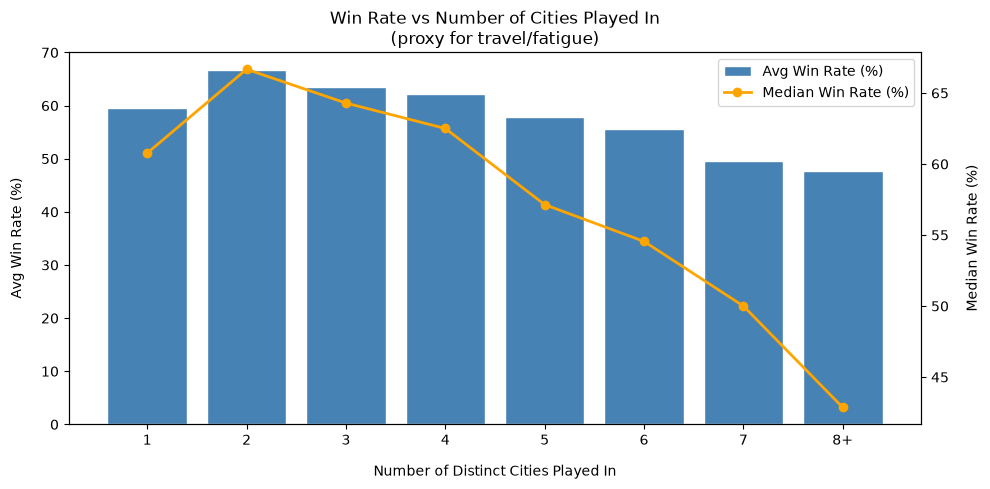

In [64]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(
    result["city_group"].astype(str),
    result["avg_win_rate"],
    color="steelblue",
    edgecolor="white",
    label="Avg Win Rate (%)")

ax1.set_xlabel("Number of Distinct Cities Played In" , labelpad= 12)
ax1.set_ylabel("Avg Win Rate (%)" , labelpad= 12)
ax1.set_title("Win Rate vs Number of Cities Played In\n(proxy for travel/fatigue)")

ax2 = ax1.twinx()
ax2.plot(
    result["city_group"].astype(str),
    result["median_win_rate"],
    color="orange", marker="o", linewidth=2, label="Median Win Rate (%)")

ax2.set_ylabel("Median Win Rate (%)" , labelpad= 12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()